### 📊 AED para explorar a Efetividade do Programa

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Sub-perguntas:**
- Como as pedras evoluem ao longo do ciclo histórico (`2020` a `2024`)?
- A mobilidade de pedras é positiva nas transições anuais e nas coortes observáveis?
- O tempo no programa influencia o desempenho?
- Os indicadores melhoram para os mesmos alunos em `2022 -> 2024` e `2023 -> 2024`?
- A efetividade varia conforme a pedra inicial e o nível inicial do aluno?


### ⚙️ Import e Setup


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../data/processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
cores_pedras = {
    'Quartzo': '#d4c5a9',
    'Ágata': '#a8c8e8',
    'Ametista': '#c8a8d4',
    'Topázio': '#f0d060'
}
mapa_pedra_num = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
mapa_colunas_pedra = {
    2020: 'pedra_20',
    2021: 'pedra_21',
    2022: 'pedra_22',
    2023: 'pedra_23',
    2024: 'pedra_24'
}


def primeiro_valido(serie):
    serie = serie.dropna()
    return serie.iloc[0] if len(serie) else np.nan


def montar_base_pedras(df):
    # Consolida o histórico de pedras em uma linha por aluno
    base = (
        df.sort_values(['RA', 'ano'])
        .groupby('RA')
        .agg({
            'ano_ingresso': primeiro_valido,
            'pedra_20': primeiro_valido,
            'pedra_21': primeiro_valido,
            'pedra_22': primeiro_valido,
            'pedra_23': primeiro_valido,
        })
    )

    pedra_24 = (
        df[df['ano'] == 2024]
        .groupby('RA')['pedra']
        .agg(primeiro_valido)
        .rename('pedra_24')
    )

    base = base.join(pedra_24)

    for col in ['pedra_20', 'pedra_21', 'pedra_22', 'pedra_23', 'pedra_24']:
        base[col] = base[col].where(base[col].isin(ordem_pedras))

    return base


def classificar_evolucao(delta):
    if pd.isna(delta):
        return np.nan
    if delta > 0:
        return 'Subiu'
    if delta < 0:
        return 'Caiu'
    return 'Manteve'


base_pedras = montar_base_pedras(df)
print(f'Alunos únicos com histórico consolidado: {base_pedras.shape[0]}')


df_base: 3030 linhas | 31 colunas
Alunos únicos com histórico consolidado: 1661


### Distribuição histórica de pedras no ciclo


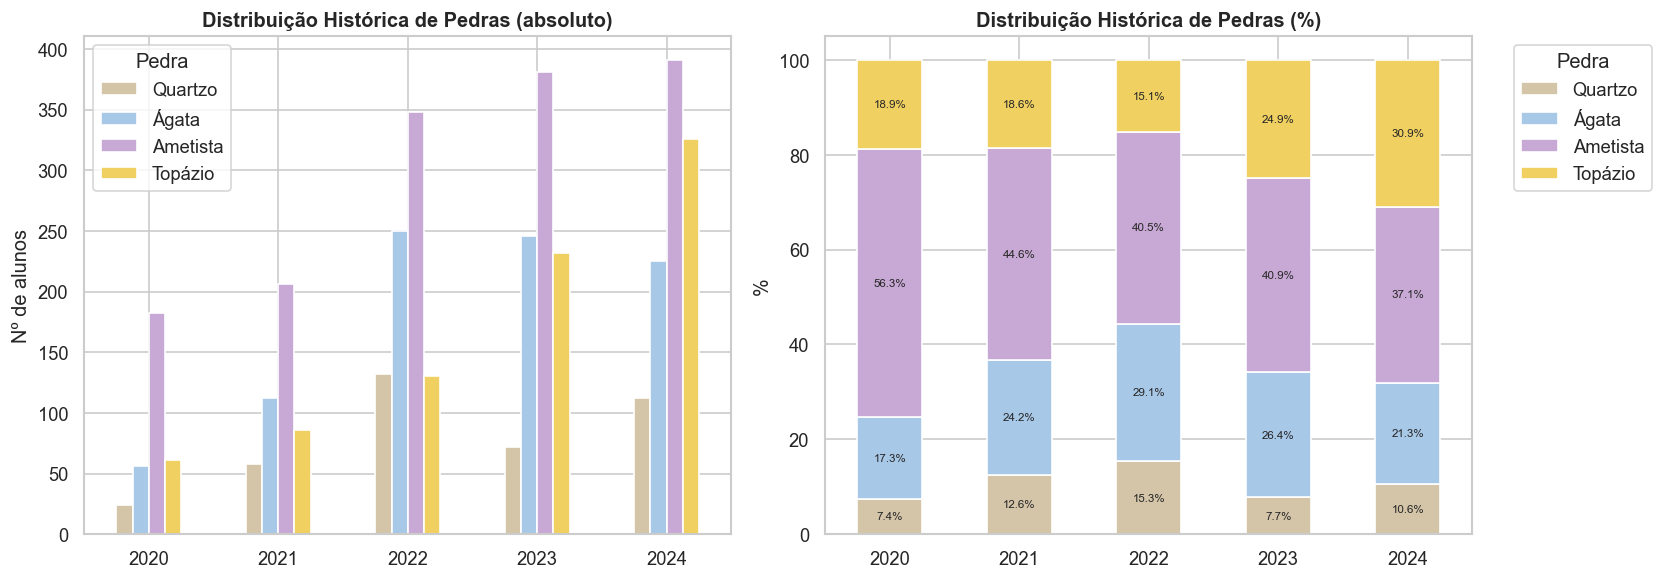

=== Distribuição histórica de pedras (%) ===
pedra  Quartzo  Ágata  Ametista  Topázio
ano                                     
2020       7.4   17.3      56.3     18.9
2021      12.6   24.2      44.6     18.6
2022      15.3   29.1      40.5     15.1
2023       7.7   26.4      40.9     24.9
2024      10.6   21.3      37.1     30.9

=== Totais absolutos ===
pedra  Quartzo  Ágata  Ametista  Topázio
ano                                     
2020        24     56       182       61
2021        58    112       206       86
2022       132    250       348      130
2023        72    246       381      232
2024       112    225       391      326


In [74]:
# Reconstrói a distribuição histórica de pedras de 2020 a 2024
base_long = (
    base_pedras.reset_index()[['RA', 'pedra_20', 'pedra_21', 'pedra_22', 'pedra_23', 'pedra_24']]
    .melt(id_vars='RA', var_name='coluna_pedra', value_name='pedra')
    .dropna()
)

base_long['ano'] = base_long['coluna_pedra'].map({
    'pedra_20': 2020,
    'pedra_21': 2021,
    'pedra_22': 2022,
    'pedra_23': 2023,
    'pedra_24': 2024,
})

ct = pd.crosstab(base_long['ano'], base_long['pedra']).reindex(columns=ordem_pedras, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=axes[0], color=[cores_pedras[p] for p in ordem_pedras])
axes[0].set_title('Distribuição Histórica de Pedras (absoluto)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de alunos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Pedra')

ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[cores_pedras[p] for p in ordem_pedras])
axes[1].set_title('Distribuição Histórica de Pedras (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Pedra', bbox_to_anchor=(1.05, 1))

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

print('=== Distribuição histórica de pedras (%) ===')
print(ct_pct.round(1).to_string())
print('\n=== Totais absolutos ===')
print(ct.to_string())


##### 💡 Insights

**A distribuição histórica de pedras não mostra melhora linear ao longo de todo o ciclo.**
- Entre `2020` e `2022`, há piora relativa na composição: `Quartzo` e `Ágata` crescem, enquanto `Ametista` e `Topázio` recuam.

**A melhora aparece com mais força a partir de `2023`.**
- O `Topázio` cresce de forma clara nos anos mais recentes, chegando a `30.9%` em `2024`, o maior valor da série.

**`2024` é o melhor retrato recente da distribuição de pedras.**
- Há menos alunos em `Ágata` e maior concentração no topo da escala, sugerindo avanço na composição geral da base.

**O ciclo parece ter duas fases distintas.**
- Uma piora até `2022` e uma recuperação em `2023–2024`.

**Os anos iniciais devem ser lidos com cautela.**
- `2020` e `2021` têm amostras menores, o que limita comparações diretas com os anos mais recentes.

❓ Mas será que essa "piora" nos primeiros anos não se deu devido a novos alunos entrando no programa?

=== Composição das pedras por status de ingresso (% do ano) ===
status_ingresso  Novato_pct  Veterano_pct  Pedra_pct
ano  pedra                                          
2020 Ametista           7.4          48.9       56.3
     Quartzo            0.3           7.1        7.4
     Topázio            4.3          14.6       18.9
     Ágata              2.8          14.6       17.3
2021 Ametista          13.2          31.5       44.7
     Quartzo            3.0           9.5       12.6
     Topázio            6.7          11.7       18.4
     Ágata              6.9          17.4       24.3
2022 Ametista          20.0          20.5       40.5
     Quartzo            5.5           9.9       15.3
     Topázio            6.7           8.4       15.1
     Ágata             14.2          14.9       29.1
2023 Ametista          16.4          24.5       40.9
     Quartzo            2.0           5.7        7.7
     Topázio           11.7          13.2       24.9
     Ágata              8.5        

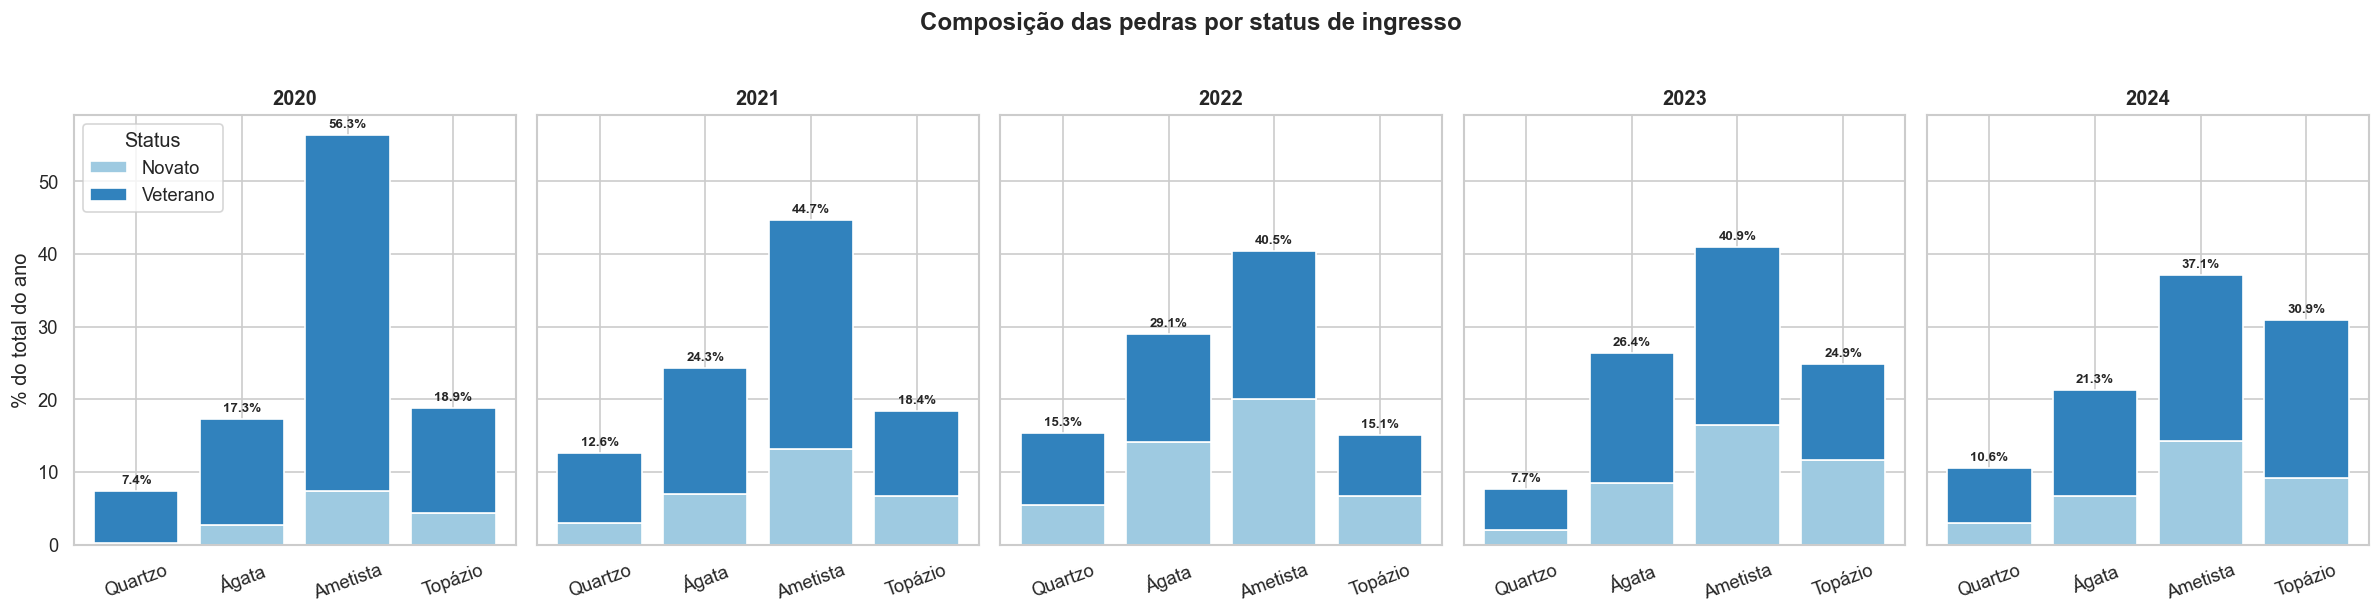

In [75]:
# Verifica se a composição de pedras em cada ano muda por entrada de novos alunos
# A ideia é decompor cada pedra em dois grupos:
# - Novato: entrou naquele mesmo ano
# - Veterano: entrou antes daquele ano

base_comp = base_pedras.reset_index()[[
    'RA', 'ano_ingresso', 'pedra_20', 'pedra_21', 'pedra_22', 'pedra_23', 'pedra_24'
]].copy()

base_comp = base_comp.melt(
    id_vars=['RA', 'ano_ingresso'],
    value_vars=['pedra_20', 'pedra_21', 'pedra_22', 'pedra_23', 'pedra_24'],
    var_name='coluna_pedra',
    value_name='pedra'
).dropna()

base_comp['ano'] = base_comp['coluna_pedra'].map({
    'pedra_20': 2020,
    'pedra_21': 2021,
    'pedra_22': 2022,
    'pedra_23': 2023,
    'pedra_24': 2024,
})

base_comp = base_comp[base_comp['pedra'].isin(ordem_pedras)].copy()

base_comp['status_ingresso'] = np.where(
    base_comp['ano_ingresso'] == base_comp['ano'],
    'Novato',
    'Veterano'
)

# Mantém apenas casos coerentes
base_comp = base_comp[base_comp['ano_ingresso'] <= base_comp['ano']].copy()

# Tabela: % de cada pedra no ano, já quebrado por status
ct = pd.crosstab(
    [base_comp['ano'], base_comp['pedra']],
    base_comp['status_ingresso']
).reindex(columns=['Novato', 'Veterano'], fill_value=0)

ct['total'] = ct.sum(axis=1)

# Percentual em relação ao total do ano
total_ano = ct.groupby(level=0)['total'].transform('sum')
ct['Novato_pct'] = ct['Novato'] / total_ano * 100
ct['Veterano_pct'] = ct['Veterano'] / total_ano * 100
ct['Pedra_pct'] = ct['total'] / total_ano * 100

print('=== Composição das pedras por status de ingresso (% do ano) ===')
print(
    ct[['Novato_pct', 'Veterano_pct', 'Pedra_pct']]
    .round(1)
    .to_string()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

cores_status = {
    'Novato': '#9ecae1',
    'Veterano': '#3182bd'
}

for ax, ano in zip(axes, [2020, 2021, 2022, 2023, 2024]):
    sub = ct.xs(ano, level=0).reindex(ordem_pedras)

    x = np.arange(len(ordem_pedras))

    ax.bar(
        x,
        sub['Novato_pct'],
        color=cores_status['Novato'],
        label='Novato'
    )
    ax.bar(
        x,
        sub['Veterano_pct'],
        bottom=sub['Novato_pct'],
        color=cores_status['Veterano'],
        label='Veterano'
    )

    ax.set_title(str(ano), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_pedras, rotation=20)
    ax.set_xlabel('')

    for i, pedra in enumerate(ordem_pedras):
        total = sub.loc[pedra, 'Pedra_pct']
        if total > 0:
            ax.text(i, total + 1, f'{total:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[0].set_ylabel('% do total do ano')
axes[0].legend(title='Status')

plt.suptitle('Composição das pedras por status de ingresso', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


##### 💡 Insights

**A mudança na distribuição de pedras não é explicada apenas pela entrada de novos alunos.**
- Há efeito de composição, mas o padrão também aparece entre os veteranos.

**A piora relativa até `2022` combina dois movimentos.**
- Crescimento da participação de novatos na base e maior presença de `Quartzo`/`Ágata` também entre veteranos.

**A melhora em `2023` e `2024` também ocorre em duas frentes.**
- Os novatos passam a entrar com perfil melhor, enquanto os veteranos avançam mais para o `Topázio`.

**Conclusão curta:** a distribuição histórica de pedras reflete tanto mudança de composição da base quanto progressão real dos alunos ao longo do ciclo.


### Mobilidade de pedras nas transições do ciclo


=== Mobilidade de pedras por transição (geral) ===
   transicao  Caiu  Manteve  Subiu   n
2020 -> 2021  32.8     52.3   14.9 323
2021 -> 2022  33.0     47.3   19.7 461
2022 -> 2023  24.4     51.2   24.4 570
2023 -> 2024  25.8     50.0   24.2 678
2020 -> 2022  44.6     41.2   14.2 323
2022 -> 2024  25.6     44.7   29.7 445

=== Mobilidade de pedras por transição e status de ingresso ===
   transicao   status  Caiu  Manteve  Subiu   n
2020 -> 2021   Novato  33.3     52.1   14.6  48
2020 -> 2021 Veterano  32.7     52.4   14.9 275
2021 -> 2022   Novato  34.1     42.8   23.2 138
2021 -> 2022 Veterano  32.5     49.2   18.3 323
2022 -> 2023   Novato  21.9     53.1   25.0 260
2022 -> 2023 Veterano  26.5     49.7   23.9 310
2023 -> 2024   Novato  30.0     51.0   18.9 243
2023 -> 2024 Veterano  23.4     49.4   27.1 435
2020 -> 2022   Novato  39.6     39.6   20.8  48
2020 -> 2022 Veterano  45.5     41.5   13.1 275
2022 -> 2024   Novato  28.3     43.4   28.3 198
2022 -> 2024 Veterano  23.5     45.

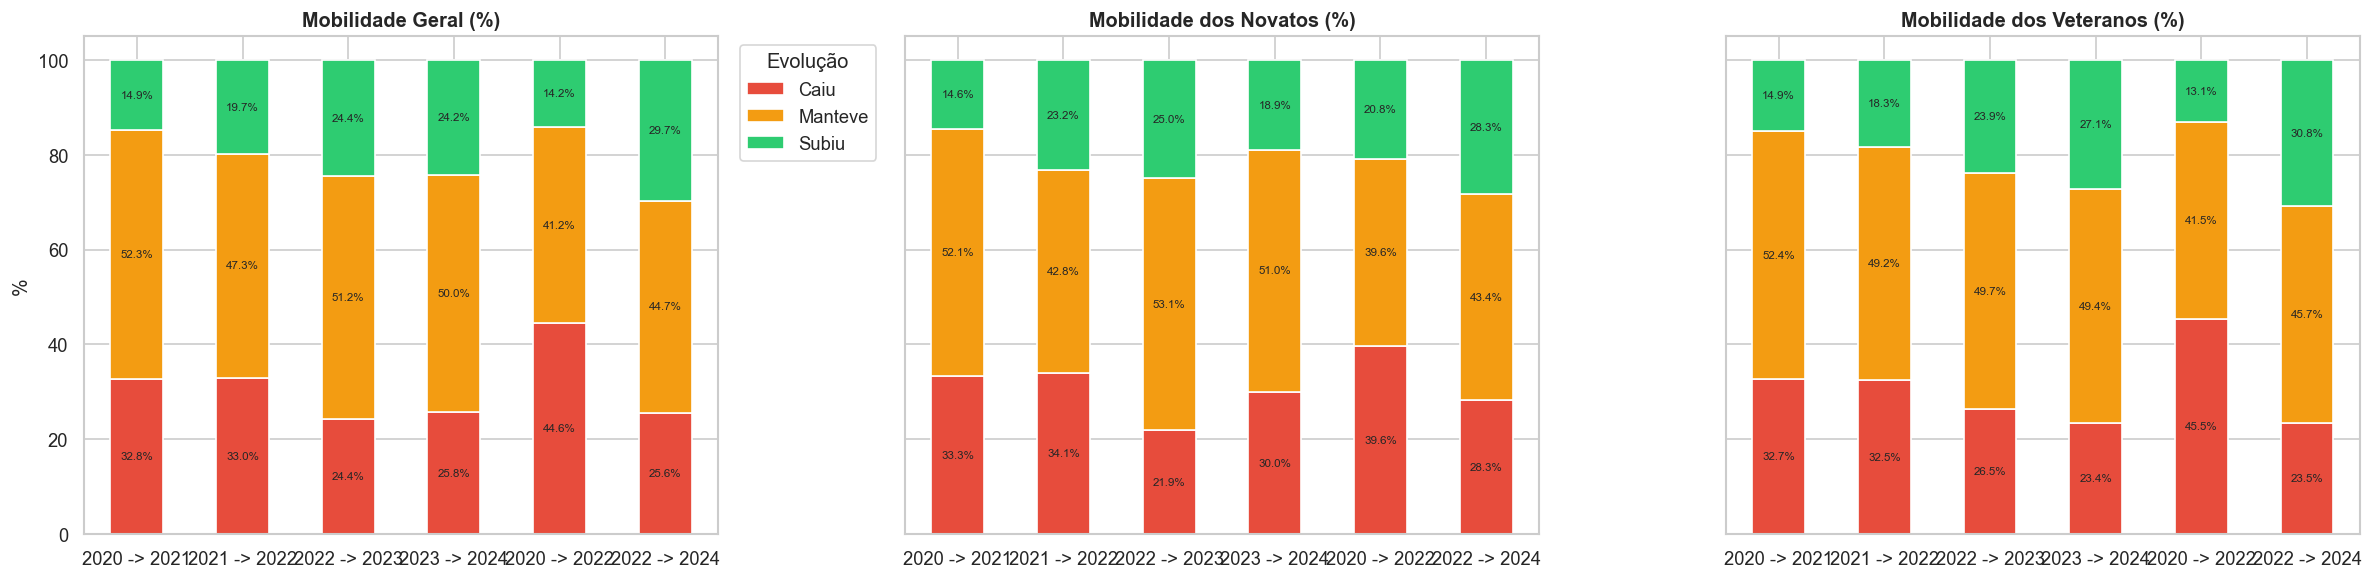

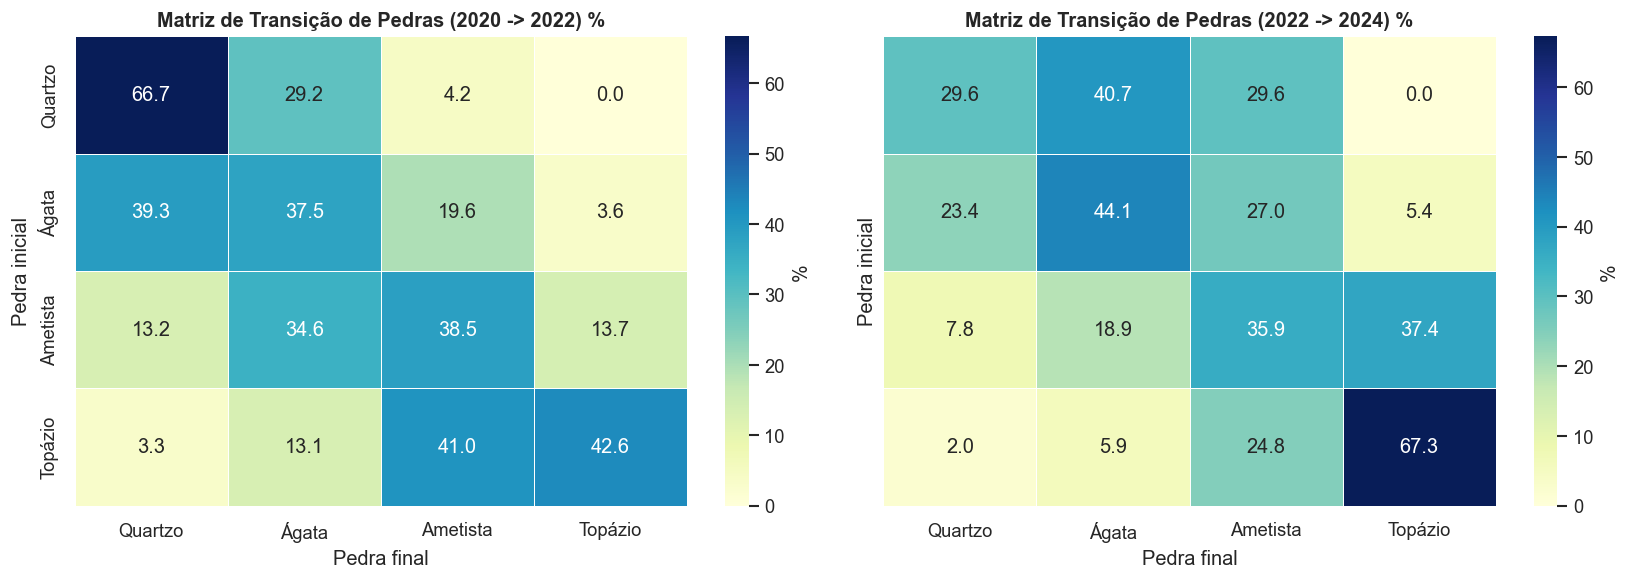

In [76]:
# Compara mobilidade nas transições anuais e em duas janelas do ciclo
# - 2020 -> 2022: período de piora relativa
# - 2022 -> 2024: período de recuperação

transicoes = [
    (2020, 2021),
    (2021, 2022),
    (2022, 2023),
    (2023, 2024),
    (2020, 2022),
    (2022, 2024),
]

rotulos_transicao = [f'{ano_ini} -> {ano_fim}' for ano_ini, ano_fim in transicoes]

resumo_transicoes_geral = []
resumo_transicoes_status = []
matriz_20_22_pct = None
matriz_22_24_pct = None

for ano_ini, ano_fim in transicoes:
    col_ini = mapa_colunas_pedra[ano_ini]
    col_fim = mapa_colunas_pedra[ano_fim]

    pares = base_pedras[[col_ini, col_fim, 'ano_ingresso']].dropna().copy()
    pares = pares[pares['ano_ingresso'] <= ano_ini].copy()

    pares['num_ini'] = pares[col_ini].map(mapa_pedra_num)
    pares['num_fim'] = pares[col_fim].map(mapa_pedra_num)
    pares['delta'] = pares['num_fim'] - pares['num_ini']
    pares['evolucao'] = pares['delta'].apply(classificar_evolucao)
    pares['status_ingresso'] = np.where(
        pares['ano_ingresso'] == ano_ini,
        'Novato',
        'Veterano'
    )

    evol_geral = (
        pares['evolucao']
        .value_counts(normalize=True)
        .reindex(['Caiu', 'Manteve', 'Subiu'], fill_value=0) * 100
    )

    resumo_transicoes_geral.append({
        'transicao': f'{ano_ini} -> {ano_fim}',
        'Caiu': evol_geral['Caiu'],
        'Manteve': evol_geral['Manteve'],
        'Subiu': evol_geral['Subiu'],
        'n': len(pares)
    })

    for status in ['Novato', 'Veterano']:
        sub = pares[pares['status_ingresso'] == status].copy()
        if len(sub) == 0:
            continue

        evol_status = (
            sub['evolucao']
            .value_counts(normalize=True)
            .reindex(['Caiu', 'Manteve', 'Subiu'], fill_value=0) * 100
        )

        resumo_transicoes_status.append({
            'transicao': f'{ano_ini} -> {ano_fim}',
            'status': status,
            'Caiu': evol_status['Caiu'],
            'Manteve': evol_status['Manteve'],
            'Subiu': evol_status['Subiu'],
            'n': len(sub)
        })

    if (ano_ini, ano_fim) == (2020, 2022):
        matriz = pd.crosstab(pares[col_ini], pares[col_fim]).reindex(
            index=ordem_pedras,
            columns=ordem_pedras,
            fill_value=0
        )
        matriz_20_22_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100

    if (ano_ini, ano_fim) == (2022, 2024):
        matriz = pd.crosstab(pares[col_ini], pares[col_fim]).reindex(
            index=ordem_pedras,
            columns=ordem_pedras,
            fill_value=0
        )
        matriz_22_24_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100

resumo_transicoes_geral = pd.DataFrame(resumo_transicoes_geral)
resumo_transicoes_status = pd.DataFrame(resumo_transicoes_status)

print('=== Mobilidade de pedras por transição (geral) ===')
print(resumo_transicoes_geral.round(1).to_string(index=False))

print('\n=== Mobilidade de pedras por transição e status de ingresso ===')
print(resumo_transicoes_status.round(1).to_string(index=False))

cores_ev = {'Caiu': '#e74c3c', 'Manteve': '#f39c12', 'Subiu': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

resumo_transicoes_geral.set_index('transicao')[['Caiu', 'Manteve', 'Subiu']].reindex(rotulos_transicao).plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[cores_ev[c] for c in ['Caiu', 'Manteve', 'Subiu']]
)
axes[0].set_title('Mobilidade Geral (%)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Evolução', bbox_to_anchor=(1.02, 1))

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

sub_novato = (
    resumo_transicoes_status[resumo_transicoes_status['status'] == 'Novato']
    .set_index('transicao')[['Caiu', 'Manteve', 'Subiu']]
    .reindex(rotulos_transicao)
    .fillna(0)
)
sub_novato.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[cores_ev[c] for c in ['Caiu', 'Manteve', 'Subiu']]
)
axes[1].set_title('Mobilidade dos Novatos (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend().remove()

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

sub_veterano = (
    resumo_transicoes_status[resumo_transicoes_status['status'] == 'Veterano']
    .set_index('transicao')[['Caiu', 'Manteve', 'Subiu']]
    .reindex(rotulos_transicao)
    .fillna(0)
)
sub_veterano.plot(
    kind='bar',
    stacked=True,
    ax=axes[2],
    color=[cores_ev[c] for c in ['Caiu', 'Manteve', 'Subiu']]
)
axes[2].set_title('Mobilidade dos Veteranos (%)', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend().remove()

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.heatmap(
    matriz_20_22_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    ax=axes[0],
    cbar_kws={'label': '%'},
    linewidths=0.5
)
axes[0].set_title('Matriz de Transição de Pedras (2020 -> 2022) %', fontweight='bold')
axes[0].set_xlabel('Pedra final')
axes[0].set_ylabel('Pedra inicial')

sns.heatmap(
    matriz_22_24_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    ax=axes[1],
    cbar_kws={'label': '%'},
    linewidths=0.5
)
axes[1].set_title('Matriz de Transição de Pedras (2022 -> 2024) %', fontweight='bold')
axes[1].set_xlabel('Pedra final')
axes[1].set_ylabel('Pedra inicial')

plt.tight_layout()
plt.show()


##### 💡 Insights

**O ciclo apresenta dois momentos bem distintos.**
- Entre `2020 -> 2022`, a mobilidade foi predominantemente negativa (`44.6%` caíram e apenas `14.2%` subiram).
- Entre `2022 -> 2024`, o saldo se inverte e a mobilidade ascendente passa a superar a descendente.

**A piora de `2020 -> 2022` não foi apenas efeito de composição.**
- Os veteranos também foram mais impactados, com `45.5%` de queda e só `13.1%` de subida.

**A melhora recente é mais consistente entre os veteranos.**
- Em `2022 -> 2024`, `30.8%` dos veteranos subiram de pedra, contra `28.3%` dos novatos, além de menor proporção de queda.

**As matrizes de transição reforçam a mudança de padrão entre os períodos.**
- Em `2020 -> 2022`, há maior retenção nas pedras baixas e perda de sustentação nas pedras altas.
- Em `2022 -> 2024`, cresce a progressão de `Quartzo` para `Ágata/Ametista` e de `Ametista` para `Topázio`, além de maior estabilidade no topo.

**Conclusão curta:** a efetividade do programa não foi constante ao longo do ciclo.
- Houve um período de deterioração até `2022` e uma recuperação mais robusta entre `2022` e `2024`, especialmente entre os alunos que permaneceram no programa.

### Tempo no programa X Desempenho


=== INDE médio por tempo no programa ===
                INDE_medio     n
tempo_programa                  
0                     7.33  1108
1                     7.32   643
2                     7.34   340
3                     7.22   437
4                     7.06   160
5                     6.85    85
6                     7.00    56
7                     6.91    16


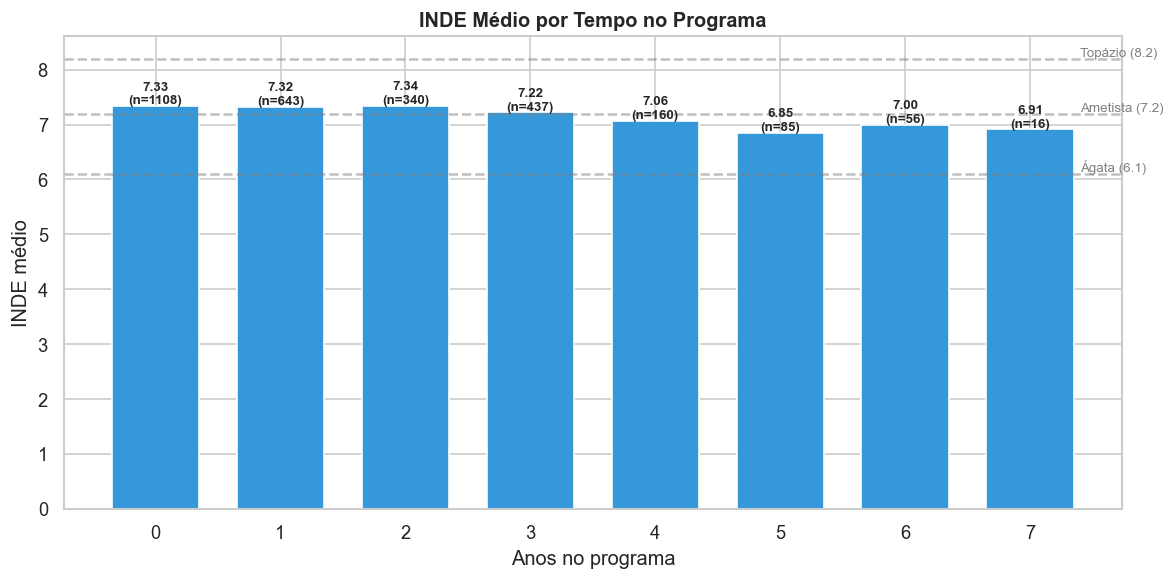

In [77]:
# Verifica se tempo bruto de permanência, sozinho, explica melhor desempenho
# Esta leitura é complementar: ela não substitui a análise longitudinal por coortes.
df_tempo = df[df['ano_ingresso'].notna() & df['INDE'].notna()].copy()
df_tempo['tempo_programa'] = df_tempo['ano'] - df_tempo['ano_ingresso']

df_tempo = df_tempo[(df_tempo['tempo_programa'] >= 0) & (df_tempo['tempo_programa'] <= 10)]

resumo_tempo = df_tempo.groupby('tempo_programa')['INDE'].agg(['mean', 'count']).round(2)
resumo_tempo.columns = ['INDE_medio', 'n']

print('=== INDE médio por tempo no programa ===')
print(resumo_tempo.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(resumo_tempo.index, resumo_tempo['INDE_medio'], color='#3498db', width=0.7)
ax.set_xlabel('Anos no programa')
ax.set_ylabel('INDE médio')
ax.set_title('INDE Médio por Tempo no Programa', fontweight='bold')
ax.set_xticks(range(int(resumo_tempo.index.max()) + 1))

for tempo, row in resumo_tempo.iterrows():
    ax.text(tempo, row['INDE_medio'] + 0.05, f'{row["INDE_medio"]:.2f}\n(n={int(row["n"])})',
            ha='center', fontsize=8, fontweight='bold')

ax.axhline(6.1, color='gray', linestyle='--', alpha=0.5)
ax.text(resumo_tempo.index.max() + 0.4, 6.15, 'Ágata (6.1)', fontsize=8, color='gray')
ax.axhline(7.2, color='gray', linestyle='--', alpha=0.5)
ax.text(resumo_tempo.index.max() + 0.4, 7.25, 'Ametista (7.2)', fontsize=8, color='gray')
ax.axhline(8.2, color='gray', linestyle='--', alpha=0.5)
ax.text(resumo_tempo.index.max() + 0.4, 8.25, 'Topázio (8.2)', fontsize=8, color='gray')

plt.tight_layout()
plt.show()


##### 💡 Insights

**O tempo no programa, isoladamente, não mostra relação clara com melhora do INDE.**
- As médias ficam praticamente estáveis entre `0` e `2` anos e depois tendem a cair.

**Não aparece um padrão de ganho acumulado ao longo da permanência.**
- Se o impacto fosse linear no tempo, seria esperado um crescimento progressivo do INDE, o que não ocorre.

**Esse resultado sugere que tempo de casa não é um bom proxy isolado de efetividade.**
- A melhora do programa parece depender mais da trajetória do aluno e do estágio no ciclo do que apenas do número de anos de permanência.

**Os grupos com maior tempo no programa devem ser lidos com cautela.**
- As amostras são menores e podem concentrar perfis mais desafiadores, o que limita comparações diretas.

### Evolução dos indicadores por pedra inicial da coorte



=== Delta médio dos indicadores por pedra inicial (2022 -> 2024 | Geral) ===
               delta_IDA  delta_IEG  delta_IAA  delta_IPS  delta_IPP  delta_IPV  delta_INDE
pedra_inicial                                                                              
Quartzo             1.95       0.58       1.84       0.49       1.42       0.71        1.10
Ágata              -0.23      -0.85       0.07      -0.02       0.83      -0.20       -0.02
Ametista           -0.68      -0.70      -0.25      -0.24       1.33      -0.29       -0.05
Topázio            -0.94      -0.21      -0.20      -0.42       1.29      -0.38       -0.17

=== Quantidade de alunos por pedra inicial ===
pedra_inicial
Quartzo     132
Ágata       250
Ametista    348
Topázio     130

=== Delta médio dos indicadores por pedra inicial (2022 -> 2024 | Novato) ===
               delta_IDA  delta_IEG  delta_IAA  delta_IPS  delta_IPP  delta_IPV  delta_INDE
pedra_inicial                                                            

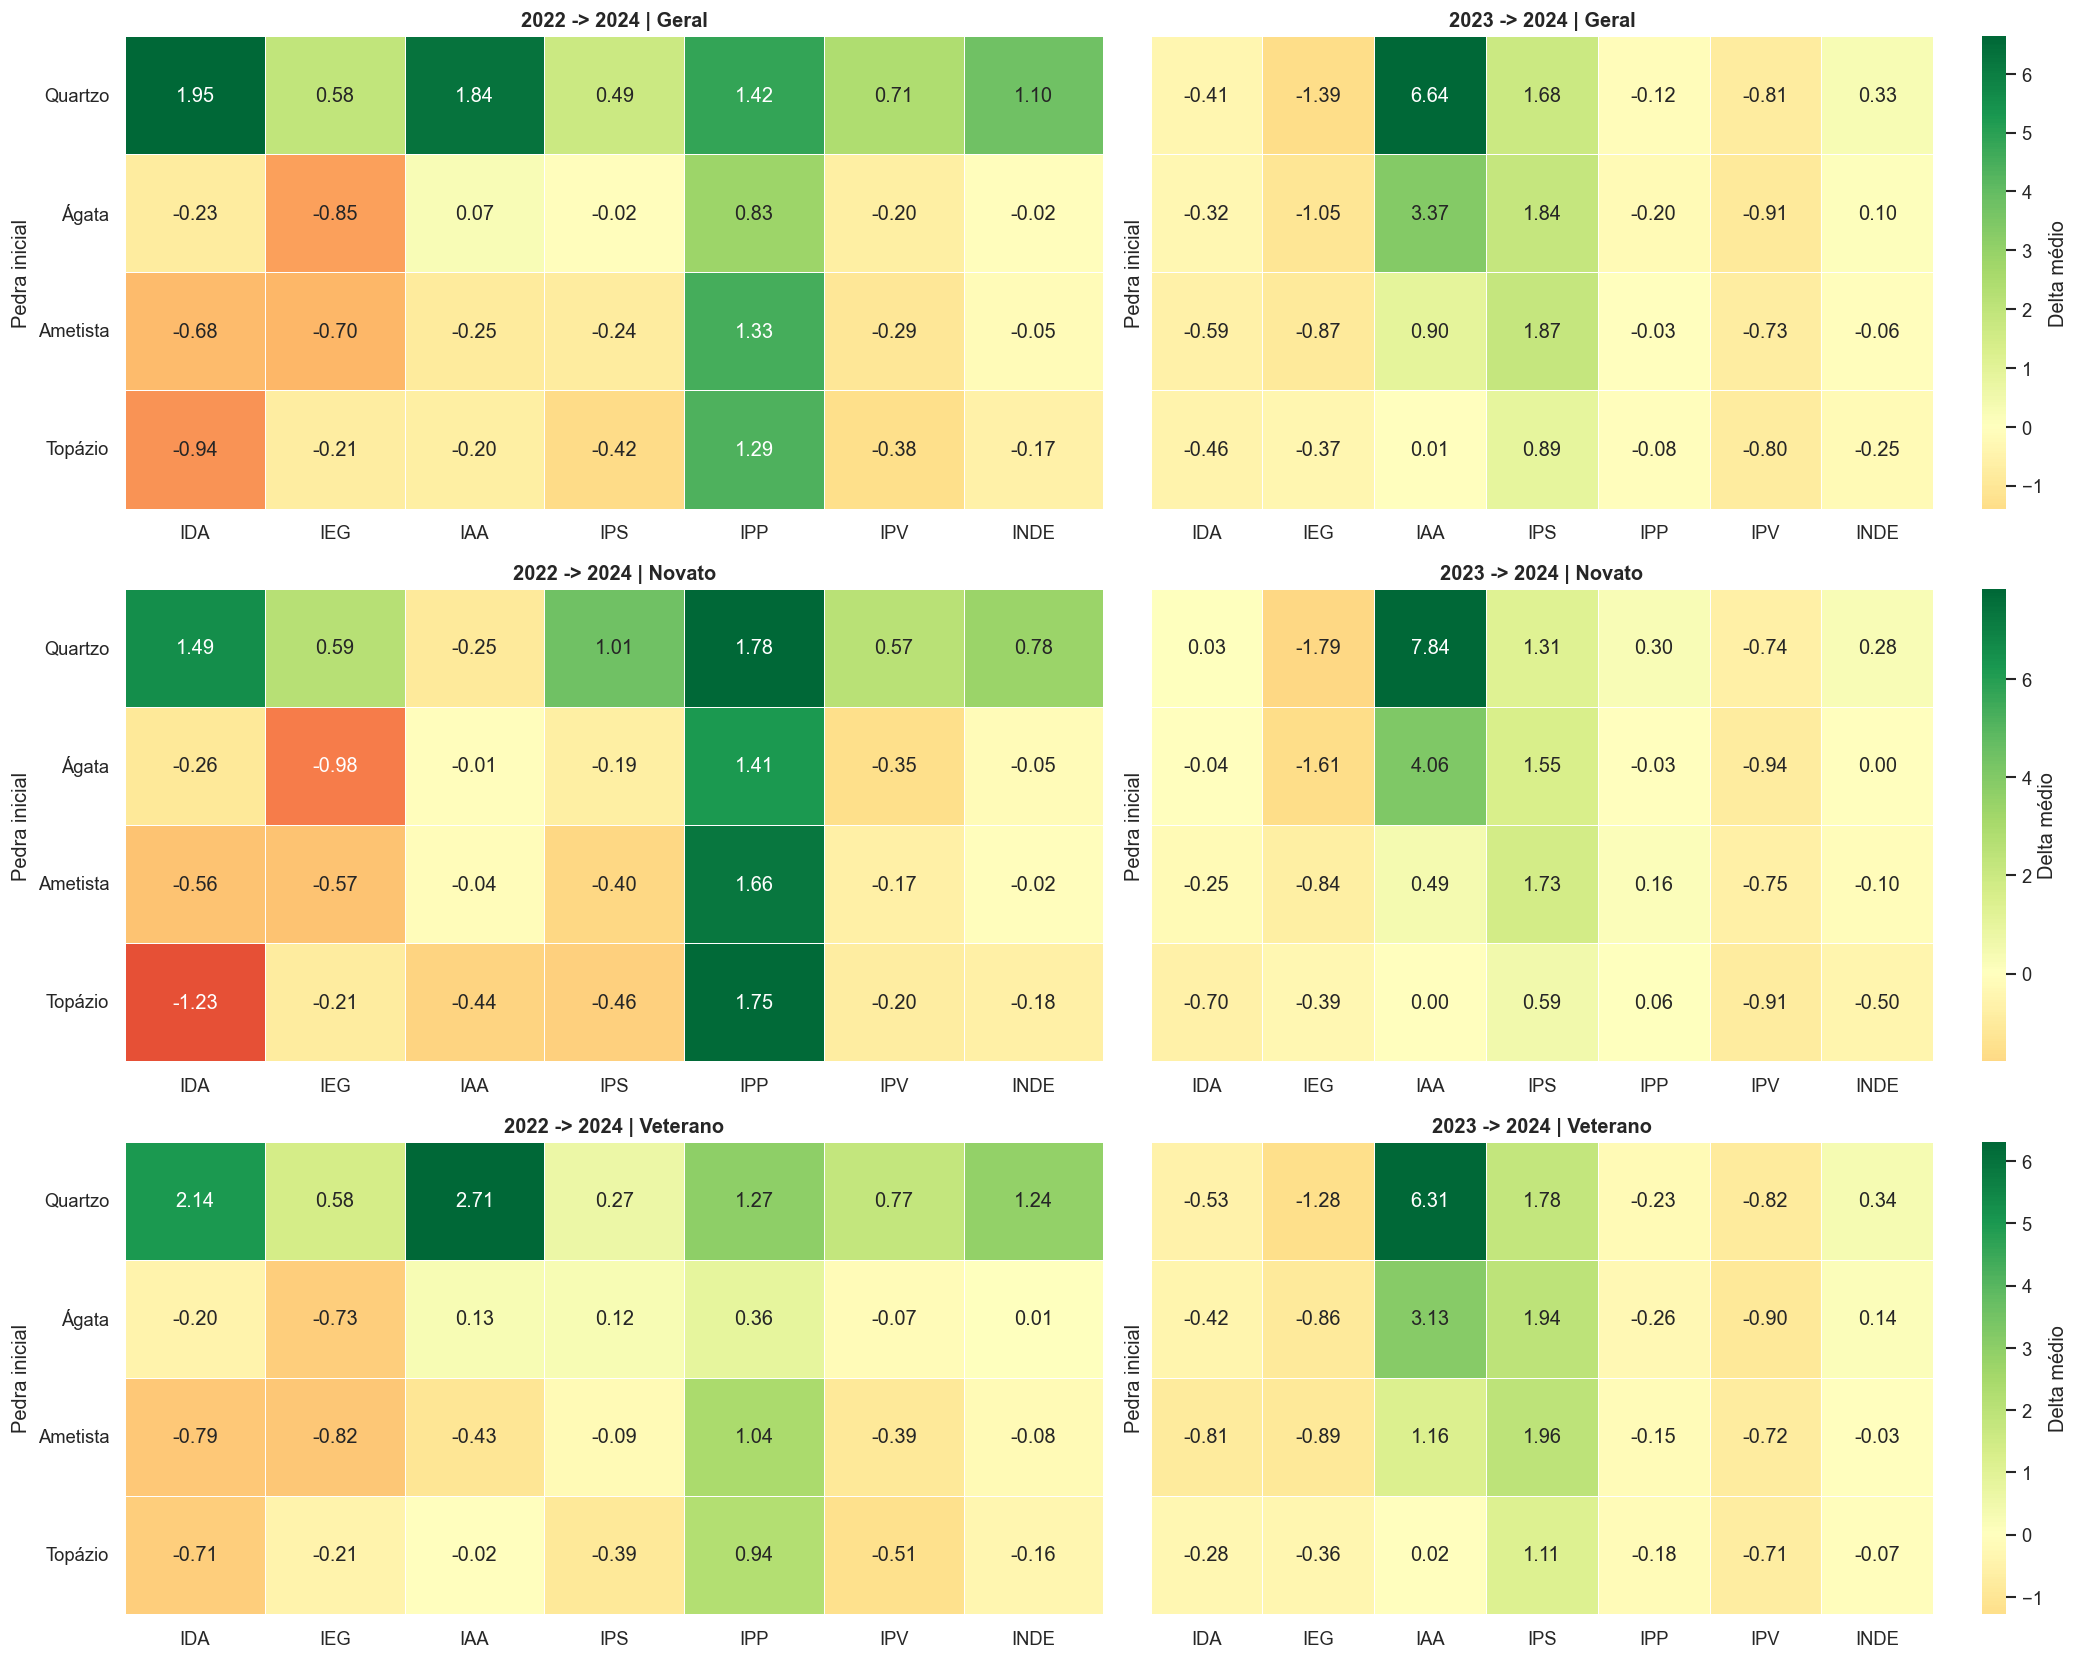

In [78]:
# Quebra a evolução dos indicadores pela pedra inicial
# A leitura mostra, lado a lado:
# - Geral
# - Novato
# - Veterano
# em cada uma das duas coortes observáveis.

coortes_pedra_ind = [
    ('2022 -> 2024', 'pedra_22', [2022, 2024]),
    ('2023 -> 2024', 'pedra_23', [2023, 2024]),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharey=True)

for col, (nome, col_pedra, anos) in enumerate(coortes_pedra_ind):
    ano_inicial = anos[0]

    base_coorte = (
        df[df['ano'].isin(anos)]
        .groupby('RA')
        .filter(lambda x: x['ano'].nunique() == 2)
        .copy()
    )

    pedra_ini = (
        base_pedras[[col_pedra, 'ano_ingresso']]
        .rename(columns={col_pedra: 'pedra_inicial'})
        .dropna(subset=['pedra_inicial', 'ano_ingresso'])
    )

    pedra_ini = pedra_ini[pedra_ini['ano_ingresso'] <= ano_inicial].copy()
    pedra_ini['status_ingresso'] = np.where(
        pedra_ini['ano_ingresso'] == ano_inicial,
        'Novato',
        'Veterano'
    )

    deltas = {}
    for ind in indicadores:
        pivot = base_coorte.pivot_table(index='RA', columns='ano', values=ind, aggfunc='first')
        deltas[ind] = pivot[anos[1]] - pivot[anos[0]]

    df_delta = pedra_ini.join(pd.DataFrame(deltas).add_prefix('delta_'))

    grupos = [
        ('Geral', df_delta.copy()),
        ('Novato', df_delta[df_delta['status_ingresso'] == 'Novato'].copy()),
        ('Veterano', df_delta[df_delta['status_ingresso'] == 'Veterano'].copy()),
    ]

    for row, (grupo, sub) in enumerate(grupos):
        ax = axes[row, col]

        resumo = (
            sub.groupby('pedra_inicial')[[f'delta_{ind}' for ind in indicadores]]
            .mean()
            .reindex(ordem_pedras)
            .round(2)
        )

        n_pedra = sub.groupby('pedra_inicial').size().reindex(ordem_pedras)

        print(f'\n=== Delta médio dos indicadores por pedra inicial ({nome} | {grupo}) ===')
        print(resumo.to_string())
        print('\n=== Quantidade de alunos por pedra inicial ===')
        print(n_pedra.to_string())

        sns.heatmap(
            resumo.rename(columns=lambda c: c.replace('delta_', '')),
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            ax=ax,
            cbar=(col == 1),
            cbar_kws={'label': 'Delta médio'}
        )

        ax.set_title(f'{nome} | {grupo}', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Pedra inicial')
        ax.set_yticklabels([
            f'{p}' if pd.notna(n_pedra[p]) else p
            for p in resumo.index
        ], rotation=0)

plt.tight_layout()
plt.show()


##### 💡 Insights

**A efetividade do programa não parece ser uniforme entre as pedras iniciais.**
- O impacto varia conforme o ponto de partida do aluno no ciclo.

**O maior avanço aparece entre os alunos que começaram no `Quartzo`.**
- Na janela `2022 -> 2024`, esse grupo melhora de forma mais clara em `IDA`, `IEG`, `IPP`, `IPV` e `INDE`.
- Entre os veteranos do `Quartzo`, esse ganho é ainda mais forte, sugerindo efeito acumulado do programa na base mais vulnerável.

**`Ágata` funciona como uma faixa de transição.**
- Os resultados ficam próximos da estabilidade no `INDE`, com ganhos mais localizados em `IPP` e, em menor grau, em aspectos subjetivos.
- Isso sugere uma etapa intermediária de consolidação, mais do que um salto amplo em todos os indicadores.

**Nas pedras mais altas (`Ametista` e `Topázio`), a efetividade aparece mais como sustentação do que como expansão.**
- Esses grupos já partem de patamares elevados, então a manutenção relativa do `INDE` e ganhos específicos, sobretudo em `IPP` e `IPS`, também podem ser lidos como resultado positivo.
- Nesses casos, o programa parece atuar mais para preservar níveis altos e fortalecer dimensões de apoio do que para gerar crescimento uniforme adicional.

**A janela `2022 -> 2024` mostra um padrão mais robusto de avanço.**
- Nela, o `IPP` cresce em praticamente todas as pedras e o `Quartzo` concentra os ganhos mais fortes no conjunto dos indicadores.
- Isso sugere que a efetividade fica mais visível com maior tempo de acompanhamento.

**Na janela curta `2023 -> 2024`, os sinais positivos se concentram mais em `IAA` e `IPS` do que em `IDA`, `IEG` e `IPV`.**
- Isso indica melhora mais evidente em dimensões subjetivas, psicossociais e de acompanhamento no curto prazo, sem o mesmo reflexo imediato no desempenho acadêmico.

**Conclusão curta**
- Nas pedras iniciais, a efetividade aparece principalmente como avanço.
- Nas pedras mais altas, ela aparece mais como sustentação de patamares já elevados, com ganhos seletivos em dimensões de apoio e desenvolvimento integral.


### Evolução dos indicadores por nível inicial da coorte



=== Delta médio dos indicadores por nível inicial (2022 -> 2024) ===
       delta_IDA  delta_IEG  delta_IAA  delta_IPS  delta_IPP  delta_IPV  delta_INDE
nivel                                                                              
ALFA       -1.00      -0.32      -0.54      -0.41       2.17      -0.38       -0.17
1          -0.94      -1.30       0.03      -0.35       1.37      -0.51       -0.12
2          -0.23      -0.94      -0.11      -0.04       1.11      -0.34        0.02
3           0.53       0.35       0.33      -0.02       0.07       0.54        0.34
4          -0.01      -0.09       0.59       0.08      -0.01       0.06        0.07
5           0.25       0.28       0.53       0.58       0.89      -0.27        0.35
6            NaN        NaN        NaN        NaN        NaN        NaN         NaN
7            NaN        NaN        NaN        NaN        NaN        NaN         NaN

=== Quantidade de alunos por nível ===
nivel
ALFA    118
1       119
2        83
3       

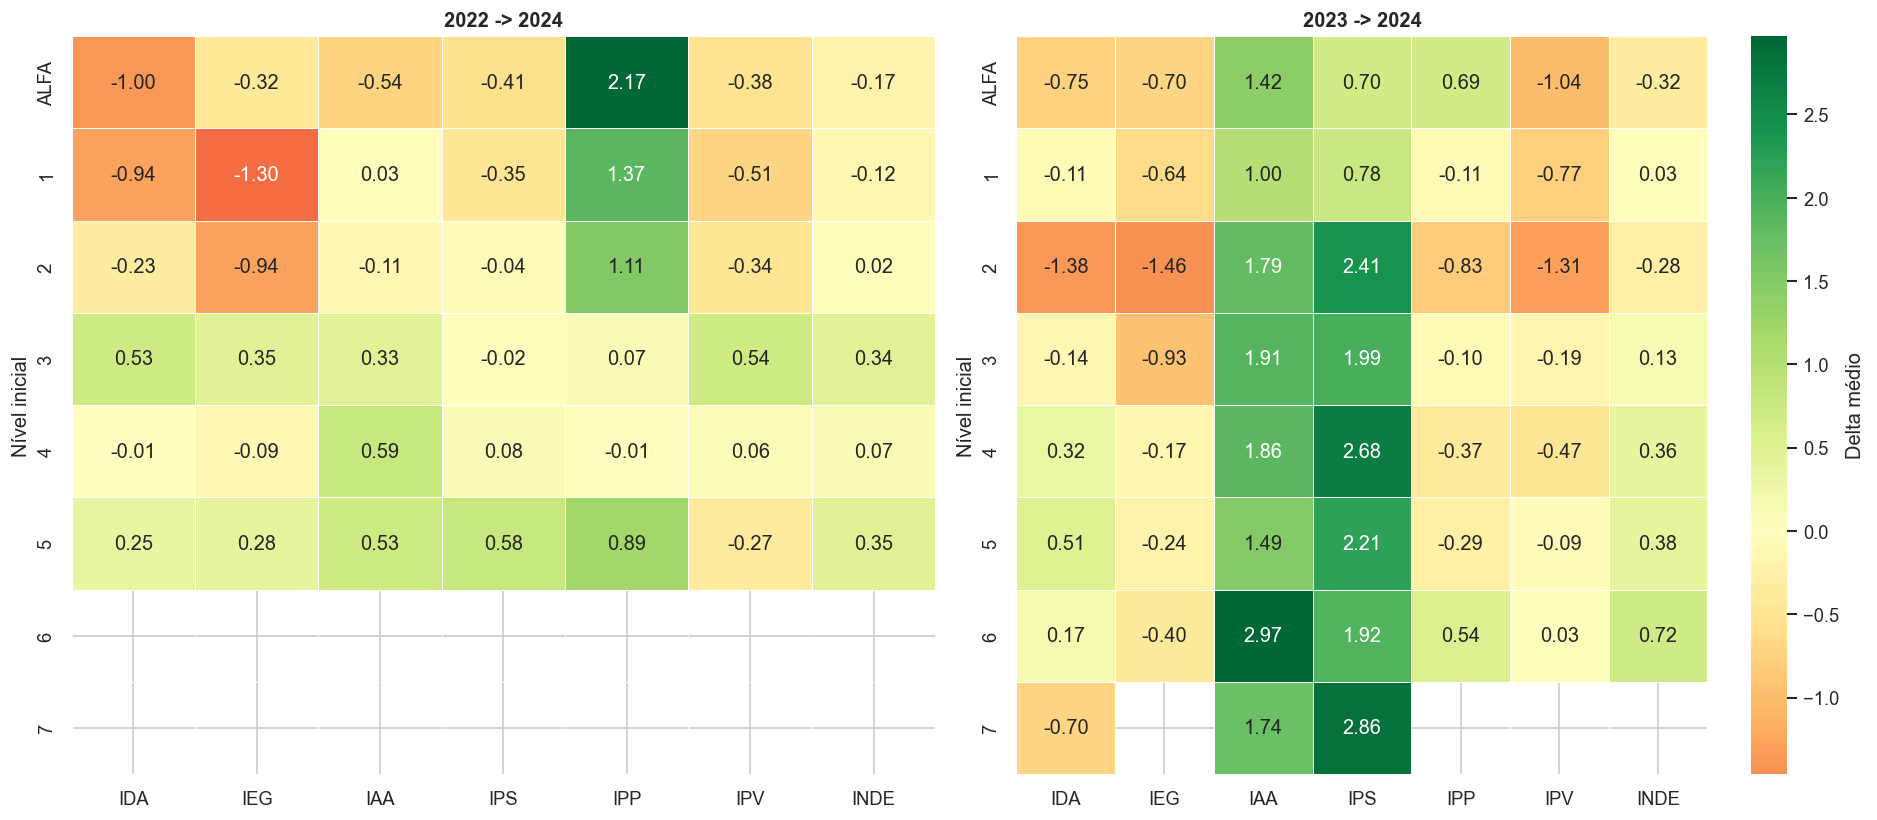

In [79]:
# Evolução dos indicadores por nível inicial — visão geral
coortes_nivel_ind = [
    ('2022 -> 2024', 2022, [2022, 2024]),
    ('2023 -> 2024', 2023, [2023, 2024]),
]

# Ordena: ALFA primeiro, depois numéricos
def ordenar_niveis(valores):
    return sorted(valores, key=lambda x: (-1, 0) if str(x) == 'ALFA' else (0, int(x)) if str(x).isdigit() else (1, str(x)))

# Todos os níveis possíveis para garantir que apareçam
todos_niveis = ['ALFA', '1', '2', '3', '4', '5', '6', '7']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for col, (nome, ano_inicial, anos) in enumerate(coortes_nivel_ind):
    base_coorte = (
        df[df['ano'].isin(anos)]
        .groupby('RA')
        .filter(lambda x: x['ano'].nunique() == 2)
        .copy()
    )

    nivel_ini = (
        base_coorte[base_coorte['ano'] == ano_inicial][['RA', 'nivel']]
        .drop_duplicates('RA')
        .set_index('RA')
    )

    deltas = {}
    for ind in indicadores:
        pivot = base_coorte.pivot_table(index='RA', columns='ano', values=ind, aggfunc='first')
        deltas[f'delta_{ind}'] = pivot[anos[1]] - pivot[anos[0]]

    df_delta = nivel_ini.join(pd.DataFrame(deltas))

    delta_cols = [f'delta_{ind}' for ind in indicadores]

    # Reindexar com todos os níveis para garantir que apareçam (NaN se não houver dados)
    resumo = df_delta.groupby('nivel')[delta_cols].mean().reindex(todos_niveis).round(2)
    n_nivel = df_delta.groupby('nivel').size().reindex(todos_niveis).fillna(0).astype(int)

    print(f'\n=== Delta médio dos indicadores por nível inicial ({nome}) ===')
    print(resumo.to_string())
    print(f'\n=== Quantidade de alunos por nível ===')
    print(n_nivel.to_string())

    sns.heatmap(
        resumo.rename(columns=lambda c: c.replace('delta_', '')),
        annot=True, fmt='.2f', cmap='RdYlGn', center=0,
        linewidths=0.5, ax=axes[col],
        cbar=(col == 1), cbar_kws={'label': 'Delta médio'}
    )

    axes[col].set_title(f'{nome}', fontweight='bold')
    axes[col].set_xlabel('')
    axes[col].set_ylabel('Nível inicial')

plt.tight_layout()
plt.show()

##### 💡 Insights

**Níveis 3 e 5 são onde o programa mostra maior efetividade (2022 → 2024):**
- Nível 3: INDE +0.34 — sobe em IDA, IEG, IAA e IPV de forma equilibrada
- Nível 5: INDE +0.35 — sobe em quase todos os indicadores, com destaque para IPS (+0.58) e IPP (+0.89)
- Nível 4: INDE +0.07 — estável, faixa de transição

**ALFA e níveis 1-2 pioram no INDE, apesar do IPP subir forte:**
- ALFA: INDE -0.17, mas IPP +2.17
- Nível 1: INDE -0.12, mas IPP +1.37
- Nível 2: INDE +0.02, mas IPP +1.11
- A subida do IPP nesses níveis é a recalibração identificada no Pilar 6 — compensa parcialmente as quedas de IDA e IEG no INDE, mas não o suficiente

**Veteranos ALFA são o grupo mais preocupante:**
- INDE -0.45, IDA -1.67, IAA -1.68 (n=28)
- Alunos que estavam na alfabetização em 2022 e permanecem no programa com desempenho caindo

**A janela 2023 → 2024 é dominada pela recuperação da anomalia de 2023:**
- IAA e IPS sobem em todos os níveis — efeito da normalização das escalas, não melhora real
- IDA e IEG caem na maioria dos níveis
- Difícil extrair tendência real nessa janela

**O nível 3 reforça o que já identificamos nos pilares anteriores:** era o gargalo acadêmico (pior IDA) e o ponto de maior superestimação (gap IAA-IDA), mas é onde o programa tem mais impacto — o aluno com mais espaço para crescer é o que mais cresce

### ⭐️ Insight Final


#### Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Sim. O programa mostra impacto real, atuando em duas frentes: elevando quem está na base e sustentando quem está no topo.**

**Síntese da efetividade no ciclo:**
- O histórico de pedras revela **dois momentos distintos**:
  - `2020 → 2022`: piora relativa da composição, com aumento de Quartzo/Ágata
  - `2022 → 2024`: recuperação clara, com crescimento do Topázio (15.1% → 30.9%)
- A mudança na distribuição **não é explicada só pela entrada de novos alunos** — houve progressão real entre os veteranos

**Mobilidade de pedras:**
- `2020 → 2022`: mobilidade predominantemente negativa (44.6% caíram, apenas 14.2% subiram)
- `2022 → 2024`: o saldo se inverte (29.7% subiram, 25.6% caíram)
- Nos anos recentes, os **veteranos** apresentam mobilidade melhor que os novatos — sinal de avanço real entre quem permaneceu no programa

**Tempo no programa:**
- O tempo bruto de permanência **não explica sozinho** a melhora do desempenho
- O INDE médio fica estável entre 0 e 2 anos e depois tende a cair
- **Tempo de casa não é um bom proxy isolado de efetividade** — a trajetória do aluno importa mais que a quantidade de anos

**Efetividade por pedra inicial:**
1. **Quartzo** — onde o impacto aparece com mais força. INDE +1.10 na coorte 2022→2024, com melhora clara em IDA, IEG, IAA, IPP, IPV
2. **Ágata** — faixa de transição. Ganhos pontuais em IPP, INDE próximo da estabilidade
3. **Ametista e Topázio** — efetividade como **sustentação**. Topázio retém 67.3% dos alunos, contrariando a tendência natural de regressão à média

**Efetividade por nível inicial:**
- Níveis 3 e 5 mostram os melhores sinais de melhora (INDE +0.34 e +0.35)
- O **nível 3** é o ponto mais completo de avanço — sobe em IDA, IEG, IAA, IPV e INDE
- ALFA e níveis 1-2 pioram no INDE apesar do IPP subir forte — a recalibração do IPP compensa parcialmente mas não o suficiente

**Conclusão executiva:**
- O impacto do programa é **heterogêneo**, e isso é um **caso de sucesso**, não uma limitação
- Nas pedras iniciais, o programa **eleva** — Quartzo com INDE +1.10 e 70.4% saindo da faixa mais baixa
- Nas pedras altas, o programa **sustenta** — Topázio retém 67.3%, contrariando a tendência natural de regressão à média
- Os dois movimentos simultâneos (base sobe, topo sustenta) confirmam o impacto real do programa em diferentes frentes

### 💡 Insights Criativos

1. **A piora de 2020→2022 coincide com a pandemia e retorno presencial:** os relatórios oficiais confirmam dificuldades de readaptação em 2022. A recuperação 2022→2024 pode refletir a estabilização do formato presencial

2. **O programa funciona de forma diferente por faixa:** Quartzo sobe, Topázio sustenta. Isso pode orientar estratégias pedagógicas diferenciadas — reforço intensivo para a base, manutenção e enriquecimento para o topo

3. **Veteranos ALFA são um grupo de atenção:** alunos na alfabetização desde 2022 com INDE caindo (-0.45, n=28). Merecem acompanhamento individualizado

**🤖 Para o modelo de ML:**
- `pedra_inicial` e `nivel_inicial` como features — o ponto de partida define trajetórias distintas
- `delta_indicador` entre anos consecutivos como feature — captura a tendência (melhorando vs piorando)
- `tempo_no_programa` tem valor limitado como feature isolada — considerar interação com nível ou pedra
- A janela 2023→2024 é contaminada pelas anomalias de escala (IAA, IPS) — features temporais devem priorizar variações normalizadas por ano